# NB02 — TF-IDF and Ranked Retrieval
### NLP Workshop Series: From Bag-of-Words to Embeddings
Claude Assisted

---

## Workshop Roadmap

```
┌─────────────────────────────────────────────────────────────────────────┐
│              NLP Workshop: From Bag-of-Words to Embeddings              │
├──────┬──────────────────────────────────────────────┬───────────────────┤
│  NB  │  Title                                       │  Status           │
├──────┼──────────────────────────────────────────────┼───────────────────┤
│  01  │  Text Preprocessing & Bag-of-Words           │  ✓ Completed      │
│  02  │  TF-IDF and Ranked Retrieval                 │  ◄ YOU ARE HERE   │
│  03  │  N-Grams and Context Windows                 │  Coming up        │
│  04  │  Word Co-occurrence and PMI                  │  Coming up        │
│  05  │  Introduction to Word Embeddings (Word2Vec)  │  Coming up        │
│  06  │  Working with Pre-trained Embeddings         │  Coming up        │
│  07  │  Sentence Embeddings and Semantic Search     │  Coming up        │
│  08  │  Putting It All Together: Mini Search Engine │  Coming up        │
└──────┴──────────────────────────────────────────────┴───────────────────┘
```

---

## What We Learned in NB01

In Notebook 1, we established the foundational pipeline for turning raw text into numerical vectors:

- **Preprocessing**: lowercase → remove punctuation → tokenize → remove stopwords → (optional) stemming
- **Vocabulary building**: collect every unique token across all 6,236 verses of the Quran (Daryabadi translation)
- **Bag-of-Words (BoW)**: represent each verse as a sparse vector of raw word counts
- **Cosine similarity**: measure how similar two BoW vectors are, ignoring vector magnitude
- **Basic keyword search**: vectorize a query and rank verses by cosine similarity

BoW gave us a working search engine. But it has a critical flaw we need to fix.

---

## The Problem That Remains

BoW treats **all words equally**. If the word `"allah"` appears 2,500+ times across the corpus and the word `"resurrection"` appears only 80 times, BoW assigns them the same importance: 1 count = 1 count.

This means a verse that says *"Allah is great, Allah is merciful, and Allah is kind"* will score highly for almost **every query** — not because it is semantically relevant, but because it contains a word that is everywhere.

---

## This Notebook's Objectives

By the end of this notebook, you will be able to:

1. Explain **why** raw word counts are a poor representation of word importance
2. Define **Term Frequency (TF)** and **Inverse Document Frequency (IDF)** mathematically
3. **Compute TF-IDF from scratch** in Python without any library
4. Use **scikit-learn's TfidfVectorizer** efficiently on a large corpus
5. Build a **ranked retrieval search engine** using TF-IDF and cosine similarity
6. Compare **BoW vs TF-IDF** results side-by-side on the same queries
7. Articulate the **remaining limitations** of TF-IDF that motivate word embeddings

---
## Section 0: Setup and Data Loading

In [2]:
print("test")

test


In [3]:
# ── Cell 0.1: Install / verify required packages ────────────────────────────
# Run this once if packages are missing. Safe to skip if already installed.
import subprocess, sys

required = ['nltk', 'scikit-learn', 'pandas', 'numpy', 'matplotlib']
for pkg in required:
    try:
        __import__(pkg.replace('-', '_').split('=')[0])
        print(f'  ✓ {pkg}')
    except ImportError:
        print(f'  Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  ✓ {pkg} installed')

  ✓ nltk
  Installing scikit-learn...
  ✓ scikit-learn installed
  ✓ pandas
  ✓ numpy
  ✓ matplotlib


In [4]:
# ── Cell 0.2: Core imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['font.size'] = 11

import string
import math
import re
from collections import Counter, defaultdict

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download required NLTK data
for resource in ['punkt', 'stopwords', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

print('All imports successful.')

All imports successful.


In [5]:
# ── Cell 0.3: Robust CSV loader ───────────────────────────────────────────────
# We try multiple relative paths so this notebook works regardless of where
# Jupyter was launched from.
import os

candidates = [
    '../quran_translations.csv',
    './quran_translations.csv',
    '../../quran_translations.csv',
    '../data/quran_translations.csv',
    './data/quran_translations.csv',
]

df_raw = None
for path in candidates:
    abs_path = os.path.abspath(path)
    if os.path.exists(abs_path):
        df_raw = pd.read_csv(abs_path)
        print(f'Dataset loaded from: {abs_path}')
        print(f'Shape: {df_raw.shape}')
        break

if df_raw is None:
    raise FileNotFoundError(
        'Could not find quran_translations.csv. '
        'Please place it one directory above this notebook or adjust the path.'
    )

# Keep only the columns we need
df = df_raw[['Surah', 'Verse', 'daryabadi']].copy()
df.dropna(subset=['daryabadi'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'\nWorking with {len(df):,} verses (Surah, Verse, daryabadi).')
print('\nFirst 3 verses:')
df.head(3)

Dataset loaded from: d:\Haq Nawaz\Teaching\NLP\BOW-to-Embeddings\quran_translations.csv
Shape: (6236, 18)

Working with 6,236 verses (Surah, Verse, daryabadi).

First 3 verses:


,Surah,Verse,daryabadi
0,1,1,"In the name of Allah, the Compassionate, the M..."
1,1,2,"All praise unto Allah, the Lord of all the wor..."
2,1,3,"The Compassionate, the Merciful."


---
## Section 0 (continued): Preprocessing Function

We redefine the same preprocessing pipeline from NB01 here so this notebook can be run **independently**. Students who already completed NB01 will recognise this function.

In [6]:
# ── Cell 0.4: Preprocessing pipeline (same as NB01) ──────────────────────────

ENGLISH_STOPWORDS = set(stopwords.words('english'))
PUNCTUATION_TABLE = str.maketrans('', '', string.punctuation)
STEMMER = PorterStemmer()

def preprocess(text: str, use_stemming: bool = False) -> list:
    """
    Full text preprocessing pipeline.

    Steps:
      1. Lowercase the text
      2. Remove all punctuation
      3. Tokenize using NLTK word_tokenize
      4. Remove English stopwords
      5. (Optional) Apply Porter stemming

    Parameters
    ----------
    text : str
        Raw verse text.
    use_stemming : bool
        If True, apply Porter stemming to every token.

    Returns
    -------
    list of str
        Cleaned and filtered tokens.
    """
    if not isinstance(text, str) or text.strip() == '':
        return []

    # Step 1 – lowercase
    text = text.lower()

    # Step 2 – remove punctuation
    text = text.translate(PUNCTUATION_TABLE)

    # Step 3 – tokenize
    tokens = word_tokenize(text)

    # Step 4 – remove stopwords and single-character tokens
    tokens = [t for t in tokens if t not in ENGLISH_STOPWORDS and len(t) > 1]

    # Step 5 – optional stemming
    if use_stemming:
        tokens = [STEMMER.stem(t) for t in tokens]

    return tokens


# Apply to every verse in the corpus
print('Preprocessing all verses...')
df['processed'] = df['daryabadi'].apply(lambda x: preprocess(x, use_stemming=False))

print(f'Done. {len(df):,} verses processed.')
print(f'\nExample — Verse 1:1')
print(f'  Original : {df.loc[0, "daryabadi"]}')
print(f'  Processed: {df.loc[0, "processed"]}')

Preprocessing all verses...
Done. 6,236 verses processed.

Example — Verse 1:1
  Original : In the name of Allah, the Compassionate, the Merciful.
  Processed: ['name', 'allah', 'compassionate', 'merciful']


---
## Section 1: Problems with Bag-of-Words

### 1.1 Equal Weighting

In Bag-of-Words, every word in the vocabulary is treated with the same importance. A word that appears in **every single document** (like `"allah"` in the Quran) contributes exactly as much as a word that appears in only **2 documents** (like `"camel"`).

This is fundamentally wrong for search. Consider:

| Word | Frequency across corpus | How distinctive is it? |
|---|---|---|
| `allah` | 2,500+ verses | Very low — it's everywhere |
| `mercy` | ~300 verses | Moderate |
| `resurrection` | ~80 verses | High — genuinely distinctive |
| `camel` | ~12 verses | Very high — rare topic |

A verse that contains `"allah"` and `"camel"` should score much higher for a camel-related query than for a generic query, but BoW gives both words count = 1 and treats them identically.

### 1.2 The Dominance Problem

Let's demonstrate this with a live example.

In [7]:
# ── Cell 1.1: Count how often key words appear across the corpus ──────────────

# Flatten all processed tokens into one big list
all_tokens = [token for verse_tokens in df['processed'] for token in verse_tokens]
token_counts = Counter(all_tokens)

# Words of interest
words_of_interest = ['allah', 'lord', 'mercy', 'day', 'resurrection', 'camel', 'patience', 'fire']

print('Word frequency across the entire Quran corpus (Daryabadi translation)')
print('=' * 60)
print(f'{"Word":<20} {"Total occurrences":<22} {"Appears in N verses"}')
print('-' * 60)

for word in words_of_interest:
    total_occ = token_counts.get(word, 0)
    # Count how many verses contain this word at least once
    verse_count = sum(1 for tokens in df['processed'] if word in tokens)
    print(f'{word:<20} {total_occ:<22} {verse_count}')

print('=' * 60)
print(f'\nTotal vocabulary size: {len(token_counts):,} unique tokens')

Word frequency across the entire Quran corpus (Daryabadi translation)
Word                 Total occurrences      Appears in N verses
------------------------------------------------------------
allah                2520                   1752
lord                 969                    860
mercy                142                    139
day                  464                    428
resurrection         40                     40
camel                4                      4
patience             22                     21
fire                 153                    146

Total vocabulary size: 6,464 unique tokens


In [8]:
# ── Cell 1.2: Build a BoW vector and show the dominance problem ───────────────

# Select a verse that contains 'allah' and a rarer word
# We'll pick the first verse where BOTH 'allah' and 'resurrection' appear
target_idx = None
for i, tokens in enumerate(df['processed']):
    if 'allah' in tokens and 'resurrection' in tokens:
        target_idx = i
        break

if target_idx is None:
    # fallback: just find a verse with 'resurrection'
    for i, tokens in enumerate(df['processed']):
        if 'resurrection' in tokens:
            target_idx = i
            break

print(f'Target verse index: {target_idx}')
print(f'Surah {df.loc[target_idx, "Surah"]}, Verse {df.loc[target_idx, "Verse"]}')
print(f'\nOriginal text:')
print(f'  "{df.loc[target_idx, "daryabadi"]}"')
print(f'\nProcessed tokens:')
print(f'  {df.loc[target_idx, "processed"]}')

# Build the BoW vector for this verse
target_tokens = df.loc[target_idx, 'processed']
bow_verse = Counter(target_tokens)

print(f'\nBoW counts for selected words:')
for word in words_of_interest:
    count = bow_verse.get(word, 0)
    bar = '█' * count
    print(f'  {word:<20} {count}  {bar}')

Target verse index: 119
Surah 2, Verse 113

Original text:
  "And the Jews say: the Nazarenes are not grounded on aught: and the Nazarenes say: the Jews are not grounded on aught While they recite the same Book. Even so say those who know not, the like of their saying. Allah will judge between them on the Day of Resurrection regarding that wherein they have been differing."

Processed tokens:
  ['jews', 'say', 'nazarenes', 'grounded', 'aught', 'nazarenes', 'say', 'jews', 'grounded', 'aught', 'recite', 'book', 'even', 'say', 'know', 'like', 'saying', 'allah', 'judge', 'day', 'resurrection', 'regarding', 'wherein', 'differing']

BoW counts for selected words:
  allah                1  █
  lord                 0  
  mercy                0  
  day                  1  █
  resurrection         1  █
  camel                0  
  patience             0  
  fire                 0  


In [9]:
# ── Cell 1.3: Visual demonstration — BoW scores vs two queries ────────────────
# We use CountVectorizer to build BoW, then show cosine similarity for two queries.

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Build a small BoW model on the full corpus
# We join processed tokens back into strings for sklearn
corpus_strings = [' '.join(tokens) for tokens in df['processed']]

bow_vectorizer = CountVectorizer(max_features=5000)
bow_matrix = bow_vectorizer.fit_transform(corpus_strings)

print(f'BoW matrix shape: {bow_matrix.shape}')
print(f'  ({bow_matrix.shape[0]} verses × {bow_matrix.shape[1]} vocabulary terms)\n')

# Query 1: generic — contains common words
query_generic = 'allah is great'
# Query 2: specific — contains rare words
query_specific = 'day of resurrection'

def bow_search(query, vectorizer, matrix, df, top_k=5):
    """Search using BoW + cosine similarity."""
    processed_q = ' '.join(preprocess(query))
    q_vec = vectorizer.transform([processed_q])
    scores = cosine_similarity(q_vec, matrix).flatten()
    top_indices = scores.argsort()[::-1][:top_k]
    results = []
    for idx in top_indices:
        results.append({
            'idx': idx,
            'Surah': df.loc[idx, 'Surah'],
            'Verse': df.loc[idx, 'Verse'],
            'score': scores[idx],
            'text': df.loc[idx, 'daryabadi'][:90] + '...'
        })
    return results

print('=== BoW Search Results ===\n')
for query in [query_generic, query_specific]:
    print(f'Query: "{query}"')
    results = bow_search(query, bow_vectorizer, bow_matrix, df)
    for r in results:
        print(f'  [{r["Surah"]}:{r["Verse"]}] score={r["score"]:.4f} | {r["text"]}')
    print()

BoW matrix shape: (6236, 5000)
  (6236 verses × 5000 vocabulary terms)

=== BoW Search Results ===

Query: "allah is great"
  [22:62] score=0.6124 | That is because Allah! He is the Truth, and because that which they call upon beside Him--...
  [4:70] score=0.5345 | That is the grace from Allah, and sufficeth Allah as Knower!...
  [59:4] score=0.5303 | That is because they opposed Allah and His apostle, and whosoever opposeth Allah, then ver...
  [4:45] score=0.5145 | And Allah is Knower of your enemies. Sufficieth Allah as a Friend and sufficieth Allah as ...
  [40:12] score=0.5000 | That is because when Allah alone was called upon ye disbelieved, and when some one was ass...

Query: "day of resurrection"
  [75:6] score=1.0000 | He asketh: when will the Day of Resurrection be?...
  [75:1] score=0.8165 | I swear by the Day of Resurrection....
  [91:3] score=0.7071 | By the day when it glorifieth him....
  [77:12] score=0.7071 | For what day is it timed?...
  [85:3] score=0.6325 | And b

### Observation

Notice that BoW results for the generic query tend to retrieve verses that contain `"allah"` everywhere — not necessarily the most relevant ones. The word `"allah"` is so common that it inflates cosine similarity scores across the board.

This is exactly the **equal-weighting problem**. We need a scoring scheme that:
- **Rewards** words that appear frequently **in this document** (they are important to it)
- **Penalises** words that appear in **almost every document** (they are not distinctive)

That is precisely what **TF-IDF** does.

---
## Section 2: TF-IDF Theory

### 2.1 Intuition

Imagine you are trying to describe what makes a particular verse **unique** within the Quran. A word like `"allah"` cannot help — it is in almost every verse, so it says nothing distinctive about this one. But a word like `"camel"` or `"resurrection"` tells you something very specific: *this verse is about that topic*.

TF-IDF captures this intuition with two components:

---

### 2.2 Term Frequency (TF)

**Definition**: How often does word `t` appear in document `d`, normalised by document length?

$$\text{TF}(t, d) = \frac{\text{count of } t \text{ in } d}{\text{total words in } d}$$

**Why normalise?** A long document naturally contains more words. Without normalisation, a 50-word verse and a 5-word verse with the same word once would be treated differently. Dividing by document length makes TF comparable across documents.

**Example**: Verse has 20 words. `"mercy"` appears 2 times.
$$\text{TF}(\text{mercy}, d) = \frac{2}{20} = 0.10$$

---

### 2.3 Inverse Document Frequency (IDF)

**Definition**: How rare is word `t` across the entire corpus of `N` documents?

$$\text{IDF}(t) = \log\left(\frac{N}{df(t)}\right)$$

where:
- `N` = total number of documents (6,236 verses)
- `df(t)` = number of documents that contain term `t` at least once
- `log` is usually natural log or log base 10 (sklearn uses natural log)

**Why the logarithm?** Without it, a word in 1 document vs 10 documents would have a ratio of 6236:623 = 10x, but a word in 10 documents vs 100 documents would also be a 10x ratio. The log compresses this so the scale is more meaningful.

**Intuition**:
- `"allah"` appears in ~2,800 verses → IDF = log(6236/2800) ≈ **0.80** (low — common word)
- `"resurrection"` appears in ~80 verses → IDF = log(6236/80) ≈ **4.36** (high — rare word)
- `"camel"` appears in ~12 verses → IDF = log(6236/12) ≈ **6.35** (very high — very rare)

---

### 2.4 TF-IDF Score

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

A word gets a **high TF-IDF score** if it:
1. Appears **frequently in this specific document** (high TF), AND
2. Is **rare across the corpus** (high IDF)

A word gets a **low TF-IDF score** if it:
- Appears rarely in this document (low TF), OR
- Appears everywhere in the corpus (low IDF — the IDF factor kills the score)

---

### 2.5 Worked Example — Three Sample Verses

Let's trace through a tiny example with 3 made-up verses:

```
Corpus (N = 3 documents):
  d1: "allah is merciful and allah is kind"
  d2: "the day of resurrection is near"
  d3: "allah will raise the dead on the day of resurrection"

Vocabulary: allah, merciful, kind, day, resurrection, near, raise, dead

──────────────────────────────────────────────────────────────────────
Step 1: Document Frequency (df) — how many docs contain each word?
  allah       → d1, d3              → df = 2
  merciful    → d1                  → df = 1
  kind        → d1                  → df = 1
  day         → d2, d3              → df = 2
  resurrection→ d2, d3              → df = 2
  near        → d2                  → df = 1
  raise       → d3                  → df = 1
  dead        → d3                  → df = 1

Step 2: IDF(t) = log(3 / df(t))
  allah        → log(3/2) = 0.405
  merciful     → log(3/1) = 1.099
  kind         → log(3/1) = 1.099
  day          → log(3/2) = 0.405
  resurrection → log(3/2) = 0.405
  near         → log(3/1) = 1.099
  raise        → log(3/1) = 1.099
  dead         → log(3/1) = 1.099

Step 3: TF for d1 = "allah is merciful and allah is kind"
  Raw tokens (after stopword removal): allah, merciful, allah, kind
  Total words = 4
  allah     → 2/4 = 0.500
  merciful  → 1/4 = 0.250
  kind      → 1/4 = 0.250

Step 4: TF-IDF for d1
  allah     → 0.500 × 0.405 = 0.203  ← LOW despite high TF, because IDF is low
  merciful  → 0.250 × 1.099 = 0.275  ← Higher score
  kind      → 0.250 × 1.099 = 0.275  ← Higher score
──────────────────────────────────────────────────────────────────────
```

Even though `"allah"` appears **twice** in d1 and `"merciful"` appears only **once**, their TF-IDF scores are almost equal — because `"allah"` is penalised by its low IDF.

---

### 2.6 ASCII Weighting Diagram

```
  Word frequency in THIS document (TF)
  ↑
  │  ██████████  "allah"      TF=high, IDF=low  → TF-IDF = MEDIUM/LOW
  │  ████        "merciful"   TF=low,  IDF=high → TF-IDF = MEDIUM/HIGH
  │  ██          "camel"      TF=low,  IDF=very high → TF-IDF = HIGH
  └─────────────────────────────────────────────────────────────────→
                           Rarity across corpus (IDF)

  The WINNER is a word that is BOTH moderately frequent here
  AND rare everywhere else.
```

---
## Section 3: Computing TF-IDF from Scratch

Before using sklearn, let's implement TF-IDF manually so we understand every calculation.

In [10]:
# ── Cell 3.1: Build document frequency table for the whole corpus ─────────────

print('Building document frequency (df) table...')

# df_table[word] = number of verses that contain 'word' at least once
df_table = defaultdict(int)

for verse_tokens in df['processed']:
    # Use a set so each word is counted only once per verse
    unique_tokens = set(verse_tokens)
    for token in unique_tokens:
        df_table[token] += 1

N = len(df)  # total number of documents (verses)

print(f'Total documents (verses): N = {N:,}')
print(f'Vocabulary size: {len(df_table):,} unique tokens')
print()

# Show df and IDF for our words of interest
print(f'{"Word":<20} {"df (# verses)":<18} {"IDF = log(N/df)"}')
print('-' * 55)
for word in words_of_interest:
    df_val = df_table.get(word, 0)
    if df_val > 0:
        idf_val = math.log(N / df_val)
    else:
        idf_val = 0.0  # word not in vocabulary
    print(f'{word:<20} {df_val:<18} {idf_val:.4f}')

Building document frequency (df) table...
Total documents (verses): N = 6,236
Vocabulary size: 6,464 unique tokens

Word                 df (# verses)      IDF = log(N/df)
-------------------------------------------------------
allah                1752               1.2696
lord                 860                1.9812
mercy                139                3.8036
day                  428                2.6790
resurrection         40                 5.0492
camel                4                  7.3518
patience             21                 5.6936
fire                 146                3.7545


In [11]:
# ── Cell 3.2: Compute TF for one verse ───────────────────────────────────────

# Pick the same verse we used in Section 1
verse_tokens = df.loc[target_idx, 'processed']
total_words = len(verse_tokens)
word_counts = Counter(verse_tokens)

print(f'Verse {df.loc[target_idx, "Surah"]}:{df.loc[target_idx, "Verse"]}')
print(f'Tokens ({total_words} total): {verse_tokens}')
print()

print(f'{"Word":<20} {"Count":<10} {"TF = count/total"}')
print('-' * 50)
for word in words_of_interest:
    count = word_counts.get(word, 0)
    tf = count / total_words if total_words > 0 else 0.0
    print(f'{word:<20} {count:<10} {tf:.6f}')

Verse 2:113
Tokens (24 total): ['jews', 'say', 'nazarenes', 'grounded', 'aught', 'nazarenes', 'say', 'jews', 'grounded', 'aught', 'recite', 'book', 'even', 'say', 'know', 'like', 'saying', 'allah', 'judge', 'day', 'resurrection', 'regarding', 'wherein', 'differing']

Word                 Count      TF = count/total
--------------------------------------------------
allah                1          0.041667
lord                 0          0.000000
mercy                0          0.000000
day                  1          0.041667
resurrection         1          0.041667
camel                0          0.000000
patience             0          0.000000
fire                 0          0.000000


In [12]:
# ── Cell 3.3: Compute TF-IDF for our words in that verse ─────────────────────

print(f'TF-IDF scores for selected words in Verse {df.loc[target_idx, "Surah"]}:{df.loc[target_idx, "Verse"]}')
print('=' * 65)
print(f'{"Word":<20} {"TF":<12} {"IDF":<12} {"TF-IDF":<12} {"Interpretation"}')
print('-' * 65)

for word in words_of_interest:
    count = word_counts.get(word, 0)
    tf = count / total_words if total_words > 0 else 0.0
    df_val = df_table.get(word, 0)
    idf = math.log(N / df_val) if df_val > 0 else 0.0
    tfidf = tf * idf

    # Interpretation
    if count == 0:
        interp = 'not in this verse'
    elif idf < 1.0:
        interp = 'common corpus word (low IDF)'
    elif idf > 4.0:
        interp = 'very distinctive word!'
    else:
        interp = 'moderately distinctive'

    print(f'{word:<20} {tf:<12.6f} {idf:<12.4f} {tfidf:<12.6f} {interp}')

print('=' * 65)
print('\n>>> KEY INSIGHT: "allah" may appear in this verse but its TF-IDF')
print('    score is pulled down by its very LOW IDF (it is everywhere).')
print('    Meanwhile "resurrection" or "camel" get HIGH TF-IDF if present.')

TF-IDF scores for selected words in Verse 2:113
Word                 TF           IDF          TF-IDF       Interpretation
-----------------------------------------------------------------
allah                0.041667     1.2696       0.052899     moderately distinctive
lord                 0.000000     1.9812       0.000000     not in this verse
mercy                0.000000     3.8036       0.000000     not in this verse
day                  0.041667     2.6790       0.111624     moderately distinctive
resurrection         0.041667     5.0492       0.210384     very distinctive word!
camel                0.000000     7.3518       0.000000     not in this verse
patience             0.000000     5.6936       0.000000     not in this verse
fire                 0.000000     3.7545       0.000000     not in this verse

>>> KEY INSIGHT: "allah" may appear in this verse but its TF-IDF
    score is pulled down by its very LOW IDF (it is everywhere).
    Meanwhile "resurrection" or "camel" g

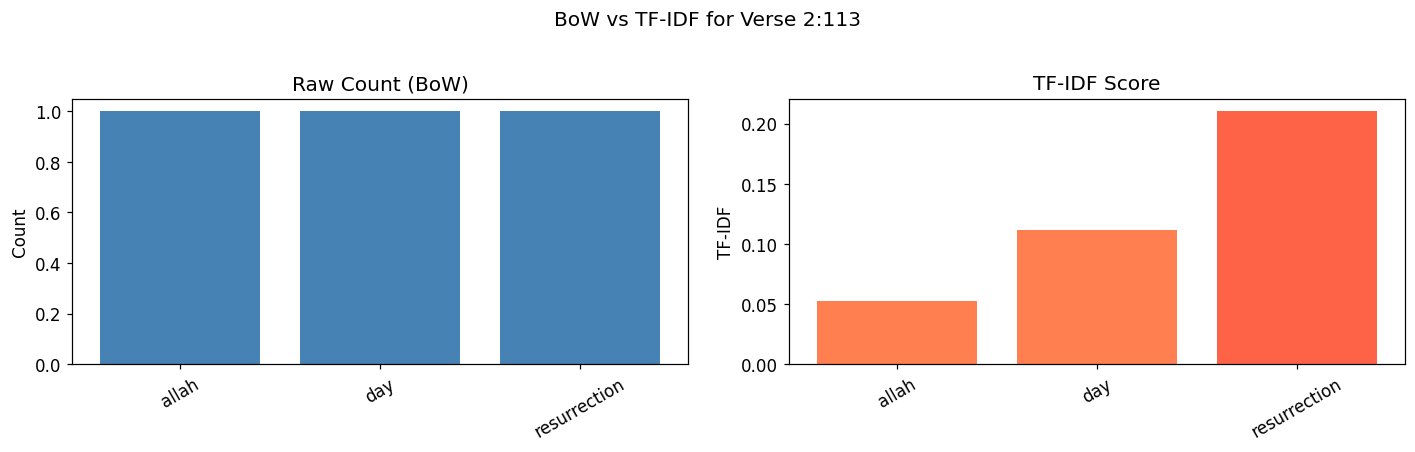

Notice how TF-IDF re-ranks the words compared to raw counts.
Common words shrink; rare words grow.


In [13]:
# ── Cell 3.4: Visualise TF-IDF vs raw count for the selected verse ────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Filter to words that actually appear in this verse
present_words = [w for w in words_of_interest if word_counts.get(w, 0) > 0]
if not present_words:
    # If none of our selected words appear, pick top 8 words in the verse
    present_words = [w for w, _ in word_counts.most_common(8)]

counts_vals = [word_counts.get(w, 0) for w in present_words]
tfidf_vals  = [
    (word_counts.get(w, 0) / total_words) * (math.log(N / df_table[w]) if df_table.get(w, 0) > 0 else 0)
    for w in present_words
]

# Left: raw BoW counts
axes[0].bar(present_words, counts_vals, color='steelblue')
axes[0].set_title('Raw Count (BoW)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Right: TF-IDF scores
colors = ['tomato' if v == max(tfidf_vals) else 'coral' for v in tfidf_vals]
axes[1].bar(present_words, tfidf_vals, color=colors)
axes[1].set_title('TF-IDF Score')
axes[1].set_ylabel('TF-IDF')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(f'BoW vs TF-IDF for Verse {df.loc[target_idx, "Surah"]}:{df.loc[target_idx, "Verse"]}', y=1.02)
plt.tight_layout()
plt.show()

print('Notice how TF-IDF re-ranks the words compared to raw counts.')
print('Common words shrink; rare words grow.')

---
## Section 4: TF-IDF with scikit-learn

Our from-scratch implementation is educational, but for the full 6,236-verse corpus we need an efficient implementation. `sklearn.feature_extraction.text.TfidfVectorizer` handles everything.

### Key Parameters

| Parameter | Value | Meaning |
|---|---|---|
| `min_df` | 2 | Ignore words that appear in fewer than 2 verses (typos, noise) |
| `max_features` | 5000 | Keep only the top 5,000 terms by TF score (memory + speed) |
| `smooth_idf` | True | Add 1 to numerator and denominator: IDF = log((1+N)/(1+df)) + 1. Prevents division by zero |
| `sublinear_tf` | True | Replace TF with log(1 + TF). Dampens very long documents |
| `norm` | 'l2' | L2-normalise each row so cosine similarity = dot product |

### Why `sublinear_tf`?

Without `sublinear_tf`, a document with 100 occurrences of a word scores 10× higher than one with 10 occurrences. But is it really 10× more relevant? Probably not — doubling the count should increase relevance, but not linearly.

`sublinear_tf=True` uses **log(1 + count)** instead of raw count:
- count=1  → log(2) = 0.69
- count=2  → log(3) = 1.10 (not 2×)
- count=10 → log(11) = 2.40 (not 10×)

This makes the scoring more robust for long documents.

In [14]:
# ── Cell 4.1: Fit TfidfVectorizer on the full corpus ─────────────────────────

from sklearn.feature_extraction.text import TfidfVectorizer

# We pass pre-processed strings (tokens joined with spaces)
# This way sklearn uses OUR preprocessing, not its own
corpus_strings = [' '.join(tokens) for tokens in df['processed']]

tfidf_vectorizer = TfidfVectorizer(
    min_df=2,           # ignore very rare terms
    max_features=5000,  # top 5000 terms only
    smooth_idf=True,    # add-1 smoothing for IDF
    sublinear_tf=True,  # use log(1+tf) for term frequency
    norm='l2'           # L2-normalise each document vector
)

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_strings)

print('TF-IDF matrix built successfully.')
print(f'  Shape  : {tfidf_matrix.shape}  ({tfidf_matrix.shape[0]} verses × {tfidf_matrix.shape[1]} terms)')

# Sparsity: fraction of zero entries
total_elements = tfidf_matrix.shape[0] * tfidf_matrix.shape[1]
nonzero = tfidf_matrix.nnz
sparsity = 1.0 - (nonzero / total_elements)
print(f'  Non-zero entries : {nonzero:,}')
print(f'  Total entries    : {total_elements:,}')
print(f'  Sparsity         : {sparsity:.2%}  (most entries are zero)')
print(f'\n  Memory (dense equivalent) would be: {total_elements * 8 / 1e6:.1f} MB')
print(f'  Memory (sparse, actual)   is about: {nonzero * 12 / 1e6:.1f} MB')

TF-IDF matrix built successfully.
  Shape  : (6236, 3598)  (6236 verses × 3598 terms)
  Non-zero entries : 62,782
  Total entries    : 22,437,128
  Sparsity         : 99.72%  (most entries are zero)

  Memory (dense equivalent) would be: 179.5 MB
  Memory (sparse, actual)   is about: 0.8 MB


In [ ]:
# Vocabulary match guard
# Both vectorizers must share the same vocabulary for a fair comparison.
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(min_df=2, max_features=5000)
bow_matrix = bow_vectorizer.fit_transform(df['processed'])

assert list(bow_vectorizer.get_feature_names_out()) == list(tfidf_vectorizer.get_feature_names_out()), \
    'Vocabulary mismatch! BoW and TF-IDF must use identical settings for a valid comparison.'

print('Vocabulary match confirmed.')
print('BoW  matrix shape :', bow_matrix.shape)
print('TFIDF matrix shape:', tfidf_matrix.shape)
print('Both share the same', bow_matrix.shape[1], 'word vocabulary.')


In [15]:
# ── Cell 4.2: Inspect IDF values — high IDF = rare = distinctive ─────────────

# sklearn stores IDF values in vectorizer.idf_
# vectorizer.get_feature_names_out() gives the vocabulary list
vocab = tfidf_vectorizer.get_feature_names_out()
idf_values = tfidf_vectorizer.idf_

# Create a DataFrame for easy sorting
idf_df = pd.DataFrame({'word': vocab, 'idf': idf_values}).sort_values('idf', ascending=False)

print('TOP 15 HIGHEST IDF words (rarest, most distinctive):')
print('-' * 40)
print(idf_df.head(15).to_string(index=False))

print('\nTOP 15 LOWEST IDF words (most common, least distinctive):')
print('-' * 40)
print(idf_df.tail(15).sort_values('idf').to_string(index=False))

print('\n--- IDF for our words of interest ---')
for word in words_of_interest:
    if word in tfidf_vectorizer.vocabulary_:
        idx = tfidf_vectorizer.vocabulary_[word]
        print(f'  {word:<20} IDF = {idf_values[idx]:.4f}')
    else:
        print(f'  {word:<20} NOT in vocabulary (filtered by min_df or max_features)')

TOP 15 HIGHEST IDF words (rarest, most distinctive):
----------------------------------------
      word      idf
 abhorrent 8.639642
   zulkifl 8.639642
       zul 8.639642
     zihar 8.639642
    zaqqum 8.639642
     abhor 8.639642
  wortheir 8.639642
     wound 8.639642
    abated 8.639642
    hellan 8.639642
    helped 8.639642
heavyladen 8.639642
   heedful 8.639642
   heights 8.639642
   heinous 8.639642

TOP 15 LOWEST IDF words (most common, least distinctive):
----------------------------------------
   word      idf
  allah 2.269171
   unto 2.314089
 verily 2.520078
  shall 2.615388
     ye 2.646512
   thou 2.823524
   lord 2.980160
   hath 3.128905
   said 3.232471
    say 3.275225
   thee 3.585522
 people 3.669829
    day 3.676798
  earth 3.811329
believe 3.822053

--- IDF for our words of interest ---
  allah                IDF = 2.2692
  lord                 IDF = 2.9802
  mercy                IDF = 4.7966
  day                  IDF = 3.6768
  resurrection         IDF = 6.

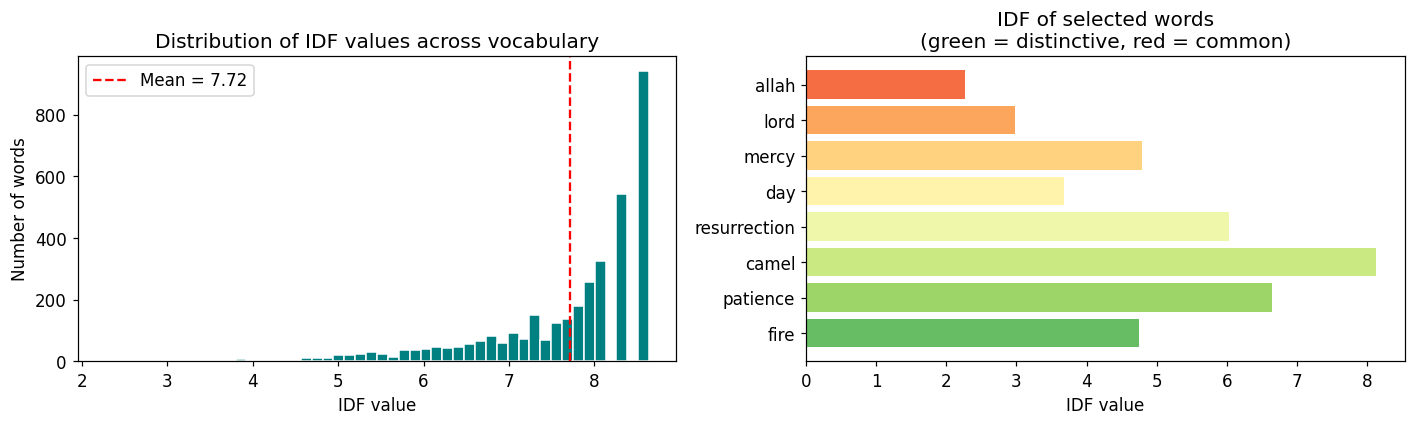

Key insight: the longer the bar, the MORE distinctive the word.
Short bars ("allah", "lord") will be DOWN-WEIGHTED in TF-IDF scoring.


In [16]:
# ── Cell 4.3: Visualise IDF distribution ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: IDF histogram
axes[0].hist(idf_values, bins=50, color='teal', edgecolor='white')
axes[0].set_xlabel('IDF value')
axes[0].set_ylabel('Number of words')
axes[0].set_title('Distribution of IDF values across vocabulary')
axes[0].axvline(np.mean(idf_values), color='red', linestyle='--', label=f'Mean = {np.mean(idf_values):.2f}')
axes[0].legend()

# Right: IDF bar for our words of interest
woi_present = [(w, idf_values[tfidf_vectorizer.vocabulary_[w]])
               for w in words_of_interest if w in tfidf_vectorizer.vocabulary_]
woi_words, woi_idf = zip(*woi_present) if woi_present else ([], [])

bar_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(woi_words)))
axes[1].barh(woi_words, woi_idf, color=bar_colors)
axes[1].set_xlabel('IDF value')
axes[1].set_title('IDF of selected words\n(green = distinctive, red = common)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('Key insight: the longer the bar, the MORE distinctive the word.')
print('Short bars ("allah", "lord") will be DOWN-WEIGHTED in TF-IDF scoring.')

---
## Section 5: TF-IDF Search Engine

Now let's build a proper search function using our TF-IDF matrix.

In [17]:
# ── Cell 5.1: tfidf_search() function ────────────────────────────────────────

def tfidf_search(query: str, vectorizer, matrix, dataframe, top_k: int = 5) -> pd.DataFrame:
    """
    Search the Quran corpus using TF-IDF + cosine similarity.

    Parameters
    ----------
    query : str
        Raw natural language query (will be preprocessed).
    vectorizer : TfidfVectorizer
        Fitted vectorizer.
    matrix : sparse matrix
        TF-IDF document matrix (n_docs × n_terms).
    dataframe : pd.DataFrame
        Original DataFrame with columns Surah, Verse, daryabadi.
    top_k : int
        Number of results to return.

    Returns
    -------
    pd.DataFrame
        Top-k results with columns: Surah, Verse, Score, Text.
    """
    # Step 1: preprocess the query using the SAME pipeline as the corpus
    processed_query = ' '.join(preprocess(query))
    print(f'  Preprocessed query: "{processed_query}"')

    # Step 2: vectorize the query using the FITTED vectorizer
    #         (unknown words are silently ignored)
    query_vec = vectorizer.transform([processed_query])

    # Step 3: compute cosine similarity between query and all documents
    #         Since both matrix and query_vec are L2-normalised, cosine sim = dot product
    scores = cosine_similarity(query_vec, matrix).flatten()

    # Step 4: rank by score and take top-k
    top_indices = scores.argsort()[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_indices, start=1):
        results.append({
            'Rank': rank,
            'Surah': dataframe.loc[idx, 'Surah'],
            'Verse': dataframe.loc[idx, 'Verse'],
            'Score': round(float(scores[idx]), 5),
            'Text': dataframe.loc[idx, 'daryabadi']
        })

    return pd.DataFrame(results)


print('tfidf_search() defined.')
print('Usage: tfidf_search("your query", tfidf_vectorizer, tfidf_matrix, df)')

tfidf_search() defined.
Usage: tfidf_search("your query", tfidf_vectorizer, tfidf_matrix, df)


In [18]:
# ── Cell 5.2: Query 1 — "allah is merciful" ──────────────────────────────────

print('=' * 70)
print('QUERY 1: "allah is merciful"')
print('=' * 70)
results1 = tfidf_search('allah is merciful', tfidf_vectorizer, tfidf_matrix, df)
print()
for _, row in results1.iterrows():
    print(f"  [{row['Rank']}] Surah {int(row['Surah'])}, Verse {int(row['Verse'])}  | Score: {row['Score']:.5f}")
    print(f"       {row['Text'][:100]}..." if len(row['Text']) > 100 else f"       {row['Text']}")
    print()

QUERY 1: "allah is merciful"
  Preprocessed query: "allah merciful"

  [1] Surah 1, Verse 3  | Score: 0.59208
       The Compassionate, the Merciful.

  [2] Surah 44, Verse 42  | Score: 0.54565
       Save those on whom Allah will have mercy. Verily He! He is the Mighty, the Merciful.

  [3] Surah 26, Verse 122  | Score: 0.54067
       And thy Lord! He is the Mighty, the Merciful.

  [4] Surah 1, Verse 1  | Score: 0.54052
       In the name of Allah, the Compassionate, the Merciful.

  [5] Surah 12, Verse 92  | Score: 0.52887
       He said; no reproach upon you today. May Allah forgive you; and He is the Most Merciful of the merci...



In [19]:
# ── Cell 5.3: Query 2 — "day of judgement and resurrection" ──────────────────

print('=' * 70)
print('QUERY 2: "day of judgement and resurrection"')
print('=' * 70)
results2 = tfidf_search('day of judgement and resurrection', tfidf_vectorizer, tfidf_matrix, df)
print()
for _, row in results2.iterrows():
    print(f"  [{row['Rank']}] Surah {int(row['Surah'])}, Verse {int(row['Verse'])}  | Score: {row['Score']:.5f}")
    print(f"       {row['Text'][:100]}..." if len(row['Text']) > 100 else f"       {row['Text']}")
    print()

QUERY 2: "day of judgement and resurrection"
  Preprocessed query: "day judgement resurrection"

  [1] Surah 75, Verse 6  | Score: 0.72046
       He asketh: when will the Day of Resurrection be?

  [2] Surah 75, Verse 1  | Score: 0.53609
       I swear by the Day of Resurrection.

  [3] Surah 39, Verse 31  | Score: 0.44343
       Then verily on the Day of Resurrection, before your Lord ye shall contend.

  [4] Surah 5, Verse 50  | Score: 0.44215
       Seek they then the judgement of Paganism? And who is better than Allah in judgement unto a people wh...

  [5] Surah 5, Verse 43  | Score: 0.39980
       And how shall they ask thee for judgement, whereas with them is the Taurat wherein is Allah's judgem...



In [20]:
# ── Cell 5.4: Query 3 — "patience in hardship" ───────────────────────────────

print('=' * 70)
print('QUERY 3: "patience in hardship"')
print('=' * 70)
results3 = tfidf_search('patience in hardship', tfidf_vectorizer, tfidf_matrix, df)
print()
for _, row in results3.iterrows():
    print(f"  [{row['Rank']}] Surah {int(row['Surah'])}, Verse {int(row['Verse'])}  | Score: {row['Score']:.5f}")
    print(f"       {row['Text'][:100]}..." if len(row['Text']) > 100 else f"       {row['Text']}")
    print()

QUERY 3: "patience in hardship"
  Preprocessed query: "patience hardship"

  [1] Surah 94, Verse 6  | Score: 0.40394
       Verily along with every hardship is ease.

  [2] Surah 94, Verse 5  | Score: 0.40394
       Then verily along with every hardship is ease.

  [3] Surah 16, Verse 42  | Score: 0.40029
       They are those who bear with patience, and in their Lord they trust.

  [4] Surah 18, Verse 67  | Score: 0.38391
       He said: verily thou wilt not be able to have with me patience;

  [5] Surah 92, Verse 10  | Score: 0.35286
       Unto him therefore We shall Indeed make easy the path to hardship.



In [ ]:
# Cell 5.5: Query 4 -- charity orphans feeding poor
# Better stress-test for TF-IDF: rare words like orphans/poor get high IDF boost.

query4 = 'charity orphans feeding poor'
print('=' * 65)
print('TF-IDF SEARCH: Query 4')
print('Query:', query4)
print('Rare words get high IDF boost here.')
print('=' * 65)

results4 = tfidf_search(query4, tfidf_vectorizer, tfidf_matrix, df, top_k=5)
for rank, (surah, verse, text, score) in enumerate(results4, 1):
    print(f'Rank {rank} | Surah {surah}, Verse {verse} | Score: {score:.4f}')
    print(' ', text[:180])
    print()

# Show IDF of query words
processed_q4 = preprocess_text(query4)
vocab = tfidf_vectorizer.vocabulary_
idf_vals = tfidf_vectorizer.idf_
print('IDF values of query words (higher = rarer = more weight):')
print(f'{"Word":<20} {"IDF"}')
print('-' * 30)
for word in processed_q4.split():
    if word in vocab:
        print(f'{word:<20} {idf_vals[vocab[word]]:.4f}')
    else:
        print(f'{word:<20} not in vocabulary')


---
## Section 6: BoW vs TF-IDF Comparison

Let's run the same query through both methods and compare results side by side. This is the most important section for understanding *why* TF-IDF is an improvement.

In [21]:
# ── Cell 6.1: Side-by-side results for the same query ────────────────────────

COMPARISON_QUERY = 'day of judgement and resurrection'

print(f'Comparison query: "{COMPARISON_QUERY}"')
print('Preprocessing:', preprocess(COMPARISON_QUERY))
print()

# --- TF-IDF results ---
print('>>> TF-IDF Search')
tfidf_res = tfidf_search(COMPARISON_QUERY, tfidf_vectorizer, tfidf_matrix, df)

# --- BoW results ---
print('\n>>> BoW Search')
bow_res_rows = bow_search(COMPARISON_QUERY, bow_vectorizer, bow_matrix, df, top_k=5)
bow_df = pd.DataFrame(bow_res_rows)

# Print side-by-side table
print()
print(f'{"Rank":<6} {"--- TF-IDF ---":<50} {"--- BoW ---"}')
print('-' * 110)

for i in range(5):
    trow = tfidf_res.iloc[i]
    brow = bow_res_rows[i]

    t_ref  = f"{int(trow['Surah'])}:{int(trow['Verse'])} (s={trow['Score']:.4f})"
    b_ref  = f"{brow['Surah']}:{brow['Verse']} (s={brow['score']:.4f})"
    t_text = trow['Text'][:40] + '...'
    b_text = brow['text'][:40]

    print(f'{i+1:<6} {t_ref:<18} {t_text:<34} {b_ref:<18} {b_text}')

print()
print('Observation: TF-IDF ranks verses that are SPECIFICALLY about resurrection')
print('higher, even if they mention "allah" less. BoW tends to surface generic verses.')

Comparison query: "day of judgement and resurrection"
Preprocessing: ['day', 'judgement', 'resurrection']

>>> TF-IDF Search
  Preprocessed query: "day judgement resurrection"

>>> BoW Search

Rank   --- TF-IDF ---                                     --- BoW ---
--------------------------------------------------------------------------------------------------------------
1      75:6 (s=0.7205)    He asketh: when will the Day of Resurrec... 75:6 (s=0.8165)    He asketh: when will the Day of Resurrec
2      75:1 (s=0.5361)    I swear by the Day of Resurrection.... 75:1 (s=0.6667)    I swear by the Day of Resurrection....
3      39:31 (s=0.4434)   Then verily on the Day of Resurrection, ... 91:3 (s=0.5774)    By the day when it glorifieth him....
4      5:50 (s=0.4421)    Seek they then the judgement of Paganism... 77:12 (s=0.5774)   For what day is it timed?...
5      5:43 (s=0.3998)    And how shall they ask thee for judgemen... 85:3 (s=0.5164)    And by the Day witnessing and the Day w

In [ ]:
# Rank drift scatter plot: BoW rank vs TF-IDF rank for the same query
# Green dots = verses promoted by TF-IDF (rank improved)
# Red dots   = verses demoted  by TF-IDF (rank dropped)
# Diagonal   = no change

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.patches import Patch

drift_query = 'charity orphans feeding poor'
top_n = 30

proc_q = preprocess_text(drift_query)
bow_q_vec = bow_vectorizer.transform([proc_q])
bow_scores = cosine_similarity(bow_q_vec, bow_matrix).flatten()

tfidf_q_vec = tfidf_vectorizer.transform([proc_q])
tfidf_scores = cosine_similarity(tfidf_q_vec, tfidf_matrix).flatten()

top_idx = np.argsort(tfidf_scores)[::-1][:top_n]
bow_ranks   = np.argsort(np.argsort(-bow_scores))
tfidf_ranks = np.argsort(np.argsort(-tfidf_scores))

bow_r    = [int(bow_ranks[i])   + 1 for i in top_idx]
tfidf_r  = [int(tfidf_ranks[i]) + 1 for i in top_idx]
labels   = [f"S{int(df.iloc[i]['Surah'])}:V{int(df.iloc[i]['Verse'])}" for i in top_idx]

fig, ax = plt.subplots(figsize=(8, 8))
max_rank = max(max(bow_r), max(tfidf_r))
ax.plot([1, max_rank], [1, max_rank], 'k--', alpha=0.3, label='No change')

for bx, tx, label in zip(bow_r, tfidf_r, labels):
    color = 'green' if tx < bx else ('red' if tx > bx else 'gray')
    ax.scatter(bx, tx, color=color, s=70, alpha=0.8, zorder=3)
    if abs(bx - tx) > 5:
        ax.annotate(label, (bx, tx), fontsize=7, ha='left', va='bottom')

legend_elements = [
    Patch(facecolor='green', label='Promoted by TF-IDF'),
    Patch(facecolor='red',   label='Demoted by TF-IDF'),
    Patch(facecolor='gray',  label='No change'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.set_xlabel('BoW Rank', fontsize=12)
ax.set_ylabel('TF-IDF Rank', fontsize=12)
ax.set_title('Rank Drift: BoW vs TF-IDF\nQuery: ' + drift_query + '\nGreen = promoted | Red = demoted | Diagonal = no change', fontsize=11, fontweight='bold')
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rank_drift_bow_vs_tfidf.png', dpi=120, bbox_inches='tight')
plt.show()
print('Rank drift plot saved as rank_drift_bow_vs_tfidf.png')


Query tokens after preprocessing: ['day', 'judgement', 'resurrection']


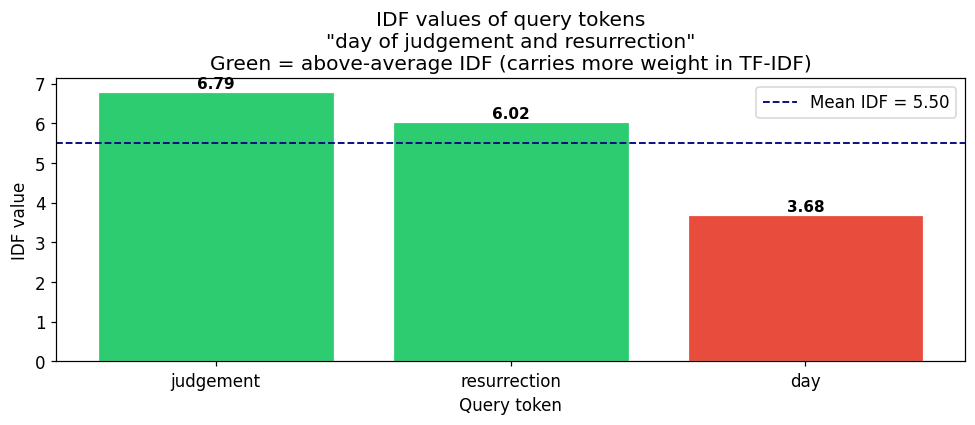


Interpretation:
  judgement            IDF=6.794  → HIGH weight
  resurrection         IDF=6.025  → HIGH weight
  day                  IDF=3.677  → low weight


In [22]:
# ── Cell 6.2: Bar chart — IDF values of query words ──────────────────────────
# This shows WHICH query words carry the most weight in TF-IDF scoring.

query_tokens = preprocess(COMPARISON_QUERY)
print(f'Query tokens after preprocessing: {query_tokens}')

# Get IDF for each query token
token_idf_pairs = []
for token in query_tokens:
    if token in tfidf_vectorizer.vocabulary_:
        idx = tfidf_vectorizer.vocabulary_[token]
        idf_val = tfidf_vectorizer.idf_[idx]
        token_idf_pairs.append((token, idf_val))
    else:
        token_idf_pairs.append((token, 0.0))  # out-of-vocab
        print(f'  Note: "{token}" not in TF-IDF vocabulary (filtered out)')

token_idf_pairs.sort(key=lambda x: x[1], reverse=True)
tokens_sorted, idfs_sorted = zip(*token_idf_pairs)

fig, ax = plt.subplots(figsize=(9, 4))

bar_colors = ['#2ecc71' if v >= np.mean(idfs_sorted) else '#e74c3c' for v in idfs_sorted]
bars = ax.bar(tokens_sorted, idfs_sorted, color=bar_colors, edgecolor='white', linewidth=0.8)

# Annotate each bar
for bar, idf_val in zip(bars, idfs_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{idf_val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(np.mean(idfs_sorted), color='navy', linestyle='--', linewidth=1.2,
           label=f'Mean IDF = {np.mean(idfs_sorted):.2f}')
ax.set_xlabel('Query token')
ax.set_ylabel('IDF value')
ax.set_title(f'IDF values of query tokens\n"{COMPARISON_QUERY}"\nGreen = above-average IDF (carries more weight in TF-IDF)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nInterpretation:')
for t, v in token_idf_pairs:
    weight = 'HIGH weight' if v > np.mean(idfs_sorted) else 'low weight'
    print(f'  {t:<20} IDF={v:.3f}  → {weight}')

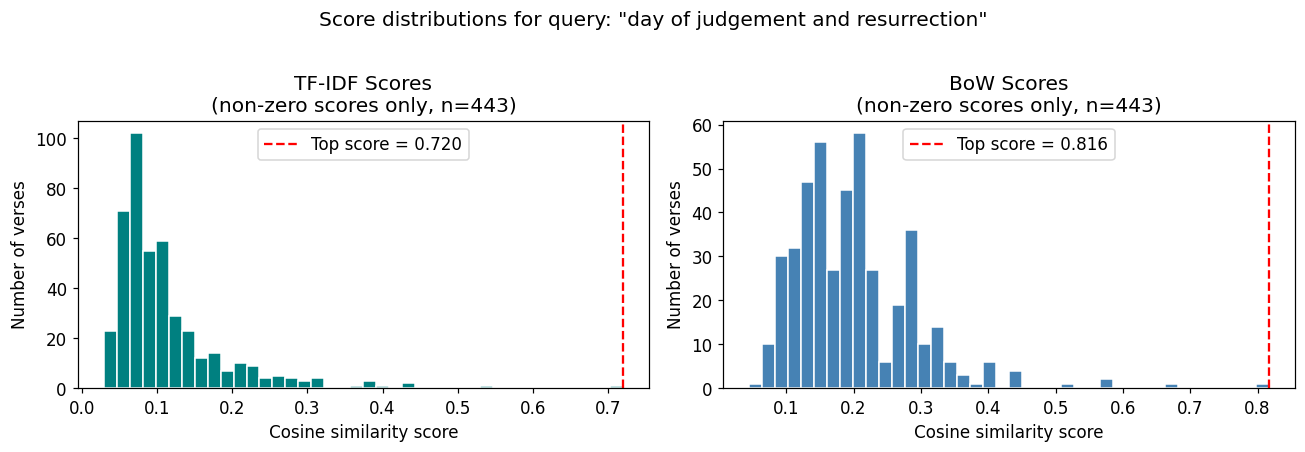

TF-IDF produces a more spread-out distribution — it discriminates better.
BoW tends to cluster scores together because common words inflate all scores.


In [23]:
# ── Cell 6.3: Score distribution comparison — violin or box plot ──────────────
# Compare how TF-IDF vs BoW distribute their similarity scores across all verses.

processed_q = ' '.join(preprocess(COMPARISON_QUERY))

# TF-IDF scores for ALL verses
tfidf_q_vec = tfidf_vectorizer.transform([processed_q])
tfidf_all_scores = cosine_similarity(tfidf_q_vec, tfidf_matrix).flatten()

# BoW scores for ALL verses
bow_q_vec = bow_vectorizer.transform([processed_q])
bow_all_scores = cosine_similarity(bow_q_vec, bow_matrix).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, scores, title, color in [
    (axes[0], tfidf_all_scores, 'TF-IDF Scores', 'teal'),
    (axes[1], bow_all_scores,  'BoW Scores',    'steelblue')
]:
    # Only show non-zero scores for clarity
    nonzero_scores = scores[scores > 0]
    ax.hist(nonzero_scores, bins=40, color=color, edgecolor='white')
    ax.set_title(f'{title}\n(non-zero scores only, n={len(nonzero_scores)})')
    ax.set_xlabel('Cosine similarity score')
    ax.set_ylabel('Number of verses')
    top_score = scores.max()
    ax.axvline(top_score, color='red', linestyle='--', label=f'Top score = {top_score:.3f}')
    ax.legend()

plt.suptitle(f'Score distributions for query: "{COMPARISON_QUERY}"', y=1.02)
plt.tight_layout()
plt.show()

print('TF-IDF produces a more spread-out distribution — it discriminates better.')
print('BoW tends to cluster scores together because common words inflate all scores.')

---
## Section 7: Inspecting TF-IDF Vectors

Let's look inside a single verse's TF-IDF vector and compare it with its BoW representation.

In [24]:
# ── Cell 7.1: Top TF-IDF scoring words in one verse ──────────────────────────

# Pick a verse with a decent number of content words
# Find a verse of moderate length (15-30 tokens after preprocessing)
moderate_verses = df[df['processed'].apply(len).between(15, 30)]
inspect_idx = moderate_verses.index[0]  # use the first match

print(f'Inspecting Verse: Surah {df.loc[inspect_idx, "Surah"]}, Verse {df.loc[inspect_idx, "Verse"]}')
print(f'\nOriginal text:')
print(f'  "{df.loc[inspect_idx, "daryabadi"]}"')
print(f'\nProcessed tokens ({len(df.loc[inspect_idx, "processed"])} tokens):')
print(f'  {df.loc[inspect_idx, "processed"]}')

# TF-IDF vector for this verse
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()
tfidf_row = tfidf_matrix[inspect_idx].toarray().flatten()

# Get top 10 by TF-IDF score
top10_tfidf_idx = tfidf_row.argsort()[::-1][:10]
top10_tfidf = [(tfidf_vocab[i], tfidf_row[i]) for i in top10_tfidf_idx if tfidf_row[i] > 0]

print(f'\nTop 10 words by TF-IDF score:')
print(f'{"Word":<20} {"TF-IDF score"}')
print('-' * 35)
for word, score in top10_tfidf:
    bar = '█' * int(score * 50)
    print(f'{word:<20} {score:.5f}  {bar}')

Inspecting Verse: Surah 2, Verse 13

Original text:
  "And when it said unto them: believe even as mankind have believed, they say: shall we believe even as the fools have believed? Lo! verily it is they who are the fools; and yet they know not."

Processed tokens (17 tokens):
  ['said', 'unto', 'believe', 'even', 'mankind', 'believed', 'say', 'shall', 'believe', 'even', 'fools', 'believed', 'lo', 'verily', 'fools', 'yet', 'know']

Top 10 words by TF-IDF score:
Word                 TF-IDF score
-----------------------------------
believed             0.49148  ████████████████████████
even                 0.45230  ██████████████████████
believe              0.36306  ██████████████████
lo                   0.29777  ██████████████
yet                  0.29146  ██████████████
mankind              0.25888  ████████████
know                 0.23748  ███████████
say                  0.18375  █████████
said                 0.18135  █████████
shall                0.14673  ███████


In [25]:
# ── Cell 7.2: Compare BoW top words vs TF-IDF top words ──────────────────────

# BoW vector for the same verse
bow_vocab = bow_vectorizer.get_feature_names_out()
bow_row = bow_matrix[inspect_idx].toarray().flatten()

top10_bow_idx = bow_row.argsort()[::-1][:10]
top10_bow = [(bow_vocab[i], int(bow_row[i])) for i in top10_bow_idx if bow_row[i] > 0]

print('BoW top 10 words (by raw count):')
print(f'{"Word":<20} {"Count"}')
print('-' * 30)
for word, count in top10_bow:
    bar = '█' * count
    print(f'{word:<20} {count}  {bar}')

print()
print('TF-IDF top 10 words (by weighted importance):')
print(f'{"Word":<20} {"TF-IDF"}')
print('-' * 35)
for word, score in top10_tfidf:
    bar = '█' * int(score * 50)
    print(f'{word:<20} {score:.5f}  {bar}')

# Find words that appear in BoW top10 but not TF-IDF top10
bow_set   = {w for w, _ in top10_bow}
tfidf_set = {w for w, _ in top10_tfidf}

demoted = bow_set - tfidf_set
promoted = tfidf_set - bow_set

print(f'\nWords DEMOTED by TF-IDF (were in BoW top10, now gone): {demoted}')
print(f'Words PROMOTED by TF-IDF (not in BoW top10, now appear): {promoted}')
print('\nTF-IDF promotes DISTINCTIVE words, BoW promotes FREQUENT words.')

BoW top 10 words (by raw count):
Word                 Count
------------------------------
fools                2  ██
even                 2  ██
believed             2  ██
believe              2  ██
said                 1  █
yet                  1  █
say                  1  █
unto                 1  █
mankind              1  █
shall                1  █

TF-IDF top 10 words (by weighted importance):
Word                 TF-IDF
-----------------------------------
believed             0.49148  ████████████████████████
even                 0.45230  ██████████████████████
believe              0.36306  ██████████████████
lo                   0.29777  ██████████████
yet                  0.29146  ██████████████
mankind              0.25888  ████████████
know                 0.23748  ███████████
say                  0.18375  █████████
said                 0.18135  █████████
shall                0.14673  ███████

Words DEMOTED by TF-IDF (were in BoW top10, now gone): {'unto', 'fools'}
Words PROM

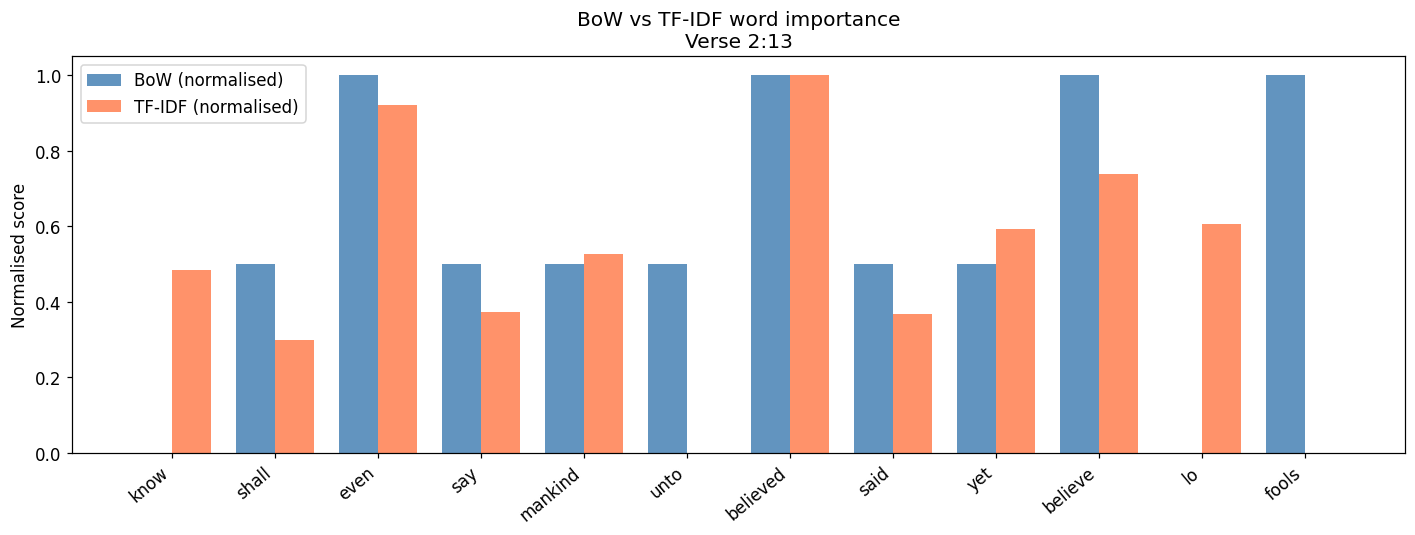

Words where the bars are very different show the biggest re-ranking effect.


In [26]:
# ── Cell 7.3: Side-by-side bar chart of BoW vs TF-IDF word importance ─────────

# Collect all words from either top-10 list
all_words = list(set([w for w, _ in top10_bow] + [w for w, _ in top10_tfidf]))

# Get normalised BoW scores (divide by max for fair comparison)
bow_dict = {w: c for w, c in top10_bow}
tfidf_dict = {w: s for w, s in top10_tfidf}

# Extend with zeros for missing words
bow_vals_plot   = [bow_dict.get(w, 0) for w in all_words]
tfidf_vals_plot = [tfidf_dict.get(w, 0.0) for w in all_words]

# Normalise BoW to [0,1] for visual comparison
bmax = max(bow_vals_plot) if max(bow_vals_plot) > 0 else 1
norm_bow = [v / bmax for v in bow_vals_plot]
tmax = max(tfidf_vals_plot) if max(tfidf_vals_plot) > 0 else 1
norm_tfidf = [v / tmax for v in tfidf_vals_plot]

x = np.arange(len(all_words))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, norm_bow,   width, label='BoW (normalised)',    color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, norm_tfidf, width, label='TF-IDF (normalised)', color='coral',     alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(all_words, rotation=40, ha='right')
ax.set_ylabel('Normalised score')
ax.set_title(f'BoW vs TF-IDF word importance\nVerse {df.loc[inspect_idx, "Surah"]}:{df.loc[inspect_idx, "Verse"]}')
ax.legend()
plt.tight_layout()
plt.show()

print('Words where the bars are very different show the biggest re-ranking effect.')

---
## Section 8: Limitations of TF-IDF

### 8.1 What TF-IDF Cannot Do

TF-IDF is a major improvement over Bag-of-Words, but it still has fundamental limitations:

#### 1. No Semantic Understanding
TF-IDF is **purely statistical**. It knows nothing about meaning. The words `"kindness"` and `"mercy"` are treated as completely unrelated terms even though they express similar concepts. A query for `"kindness to parents"` will fail to retrieve verses about `"mercy towards parents"` unless the exact word `"kindness"` appears.

#### 2. No Word Order
Like BoW, TF-IDF treats a document as a **set of weighted terms**. The sentences:
- *"Allah forgives the believers"*
- *"The believers forgive Allah"* (theologically strange, but illustrative)

would produce identical TF-IDF vectors. Context and grammar are lost.

#### 3. Sparsity
The TF-IDF matrix has 6,236 × 5,000 = 31 million cells, yet only ~0.6% are non-zero. Most verses share very few exact words. This makes nearest-neighbour search expensive for very large corpora.

#### 4. Corpus Bias in IDF
IDF is a **global corpus statistic**. In the Quran, `"allah"` has a very low IDF — not because the concept is unimportant, but because the text mentions it constantly. If we added a million Wikipedia articles to the corpus, `"allah"` would gain a higher IDF simply because most Wikipedia articles do not mention it. The IDF value depends entirely on what other documents are in your collection.

#### 5. Vocabulary Mismatch
If a user queries a word that was filtered out (appears in fewer than `min_df=2` verses), TF-IDF returns nothing for that term. Out-of-vocabulary words are silently ignored.

In [27]:
# ── Cell 8.1: Failure demo — semantic gap ─────────────────────────────────────
# Query: "kindness to parents"
# Expected: verses about being merciful, respectful, or dutiful to parents
# Actual: only retrieves verses that contain the exact word 'kindness'

FAILURE_QUERY = 'kindness to parents'

print('=' * 70)
print(f'Failure Demo: TF-IDF for "{FAILURE_QUERY}"')
print('=' * 70)

processed_fail = preprocess(FAILURE_QUERY)
print(f'Preprocessed query tokens: {processed_fail}')
print()

# Check which query words survive preprocessing and are in vocabulary
for token in processed_fail:
    if token in tfidf_vectorizer.vocabulary_:
        idx = tfidf_vectorizer.vocabulary_[token]
        idf = tfidf_vectorizer.idf_[idx]
        print(f'  "{token}" → in vocabulary, IDF = {idf:.4f}')
    else:
        print(f'  "{token}" → NOT in TF-IDF vocabulary (filtered out)')

print()
results_fail = tfidf_search(FAILURE_QUERY, tfidf_vectorizer, tfidf_matrix, df)
for _, row in results_fail.iterrows():
    print(f"  [{row['Rank']}] {int(row['Surah'])}:{int(row['Verse'])}  score={row['Score']:.5f}")
    print(f"       {row['Text'][:110]}")
    print()

print('-' * 70)
print('Compare with a SEMANTIC query that should retrieve the same verses:')
print('Query: "mercy to parents" — note: TF-IDF still cannot bridge the gap')
print('between "kindness" and "mercy". Only word embeddings can do that.')

Failure Demo: TF-IDF for "kindness to parents"
Preprocessed query tokens: ['kindness', 'parents']

  "kindness" → in vocabulary, IDF = 7.2533
  "parents" → in vocabulary, IDF = 6.6028

  Preprocessed query: "kindness parents"
  [1] 55:60  score=0.58685
       Shall the recompense of kindness be aught save kindness?

  [2] 29:8  score=0.42356
       And We have enjoined on man kindness unto parents. But if the twain strive to make thee associate with Me that

  [3] 17:23  score=0.40161
       And thy Lord hath decreed that ye shall Worship none but Him, and unto parents shew kindness; and if either of

  [4] 14:41  score=0.30510
       Our Lord! forgive me and my parents and the believers on the Day whereon will be set up the reckoning.

  [5] 4:36  score=0.28699
       And worship Allah and associate not aught with Him; and unto parents show kindness, and also unto kindred and 

----------------------------------------------------------------------
Compare with a SEMANTIC query that sh

In [28]:
# ── Cell 8.2: Show corpus bias in IDF ────────────────────────────────────────
# Demonstrate that IDF is a corpus statistic, not a measure of conceptual importance.

print('IDF values in the Quran corpus vs conceptual importance:')
print()
print(f'{"Word":<25} {"IDF in Quran corpus":<25} {"Comment"}')
print('-' * 75)

important_words = {
    'allah': 'Theologically central — but low IDF because everywhere',
    'prophet': 'Important concept — moderate IDF',
    'pray': 'Core practice — check IDF',
    'resurrection': 'Key theological event — high IDF (few verses)',
    'camel': 'Mentioned rarely — very high IDF',
    'mercy': 'Core attribute — moderate IDF',
}

for word, comment in important_words.items():
    if word in tfidf_vectorizer.vocabulary_:
        idx = tfidf_vectorizer.vocabulary_[word]
        idf = tfidf_vectorizer.idf_[idx]
        print(f'{word:<25} {idf:<25.4f} {comment}')
    else:
        print(f'{word:<25} {"(not in vocab)":<25} {comment}')

print()
print('Key takeaway: Low IDF ≠ Unimportant. It just means the word is common')
print('IN THIS CORPUS. Add a million news articles, and IDF values shift completely.')

IDF values in the Quran corpus vs conceptual importance:

Word                      IDF in Quran corpus       Comment
---------------------------------------------------------------------------
allah                     2.2692                    Theologically central — but low IDF because everywhere
prophet                   5.7493                    Important concept — moderate IDF
pray                      7.3404                    Core practice — check IDF
resurrection              6.0247                    Key theological event — high IDF (few verses)
camel                     8.1288                    Mentioned rarely — very high IDF
mercy                     4.7966                    Core attribute — moderate IDF

Key takeaway: Low IDF ≠ Unimportant. It just means the word is common
IN THIS CORPUS. Add a million news articles, and IDF values shift completely.


---
## Section 9: Student Reflection Questions

These questions are designed to test your understanding of the concepts covered in this notebook. Attempt them before reading the hints.

---

### Question 1
**Why does the word `"allah"` receive a LOW TF-IDF score in the Quran corpus, even though it is theologically the most central word in the text?**

*Think about:* What is IDF measuring? What does it mean for a word to appear in nearly every verse?

*Hint:* IDF = log(N / df). If df ≈ N (word appears in almost every document), then IDF → log(1) → 0.

---

### Question 2
**Suppose we combined the Quran corpus with 1 million English news articles. How would the IDF values of the following words change, and why?**

| Word | IDF in Quran only | IDF after adding news | Direction |
|---|---|---|---|
| `allah` | low | ? | |
| `president` | very high (rare) | ? | |
| `the` | filtered out | ? | |
| `resurrection` | high | ? | |

*Think about:* The news articles would contain `"president"` constantly but almost never `"resurrection"` or `"allah"`.

---

### Question 3
**Why does `sublinear_tf=True` (which uses log(1+tf) instead of raw tf) help for long documents?**

Consider two verses:
- Verse A: 10 words, `"mercy"` appears 2 times → raw TF = 0.20
- Verse B: 100 words, `"mercy"` appears 10 times → raw TF = 0.10

With `sublinear_tf`:
- Verse A: log(1+2) = 1.099 → normalised TF = 1.099/10 ≈ 0.110
- Verse B: log(1+10) = 2.398 → normalised TF = 2.398/100 ≈ 0.024

Does using log dampen the difference between counting 2 vs 10 times? Is this desirable?

---

### Question 4
**Find a query where TF-IDF clearly outperforms BoW in your opinion. Run both searches in the code cell below and explain WHY TF-IDF gives better results for that specific query.**

*Hint:* Try queries with a mix of common and rare words. Queries like `"fire and brimstone"`, `"honey and milk"`, or `"patience of the righteous"` might show interesting differences.

In [29]:
# ── Cell 9.4 (Student exercise): Compare BoW vs TF-IDF for YOUR chosen query ──

# TODO: Replace this query with one you think will show a clear difference
STUDENT_QUERY = 'fire and punishment'  # <-- change this

print(f'Student query: "{STUDENT_QUERY}"')
print(f'Preprocessed: {preprocess(STUDENT_QUERY)}')
print()

print('TF-IDF results:')
tfidf_student = tfidf_search(STUDENT_QUERY, tfidf_vectorizer, tfidf_matrix, df)
for _, r in tfidf_student.iterrows():
    print(f"  [{r['Rank']}] {int(r['Surah'])}:{int(r['Verse'])} (s={r['Score']:.4f}) | {r['Text'][:80]}...")

print()
print('BoW results:')
bow_student = bow_search(STUDENT_QUERY, bow_vectorizer, bow_matrix, df)
for r in bow_student:
    print(f"  [{r['idx']}] {r['Surah']}:{r['Verse']} (s={r['score']:.4f}) | {r['text'][:80]}")

print()
print('--- Write your analysis below ---')
print('# Which method gives better results? Why?')
print('# Which query words have high IDF? Which have low IDF?')

Student query: "fire and punishment"
Preprocessed: ['fire', 'punishment']

TF-IDF results:
  Preprocessed query: "fire punishment"
  [1] 85:5 (s=0.5203) | Of fire fuel-fed,...
  [2] 104:6 (s=0.4695) | Fire of Allah, Kindled,...
  [3] 79:25 (s=0.4469) | Wherefore Allah laid hold of him with the punishment of the Hereafter and of the...
  [4] 5:38 (s=0.4007) | As for the man-thief and the woman-thief, cut off their hands as a meed for that...
  [5] 42:31 (s=0.3883) | And ye cannot frustrate His Punishment in the earth; and there is for you beside...

BoW results:
  [5913] 85:5 (s=0.7071) | Of fire fuel-fed,...
  [6184] 104:6 (s=0.5000) | Fire of Allah, Kindled,...
  [5536] 74:42 (s=0.4082) | What led you into the Scorching Fire?...
  [6042] 90:20 (s=0.4082) | Over them shall be Fire closing round....
  [6167] 101:11 (s=0.4082) | A Fire vehemently hot!...

--- Write your analysis below ---
# Which method gives better results? Why?
# Which query words have high IDF? Which have low IDF?


### Question 5
**What does TF-IDF still NOT solve?**

List at least three things that TF-IDF cannot do, even with perfect implementation. For each, explain how word embeddings (covered in NB05) would address it.

| Problem | TF-IDF limitation | How embeddings help |
|---|---|---|
| Synonyms | `"mercy"` ≠ `"kindness"` — different tokens | Embeddings place synonyms close in vector space |
| Word order | `"God forgives man"` = `"Man forgives God"` | Sentence embeddings encode order |
| Context | `"bank"` (river) = `"bank"` (finance) | Contextualised embeddings (BERT) differ per context |
| ? | ... | ... |
| ? | ... | ... |

---

*These questions will be discussed in the next workshop session.*

---
## Section 10: Summary and What's Next

### What We Covered in This Notebook

| Topic | Key Concept | Code |
|---|---|---|
| BoW limitations | Equal weighting problem | `CountVectorizer`, `Counter` |
| Term Frequency | count(t,d) / len(d) | Manual Python implementation |
| Inverse Document Frequency | log(N / df(t)) | Manual Python + sklearn |
| TF-IDF score | TF × IDF | `TfidfVectorizer` |
| Sparsity | 99%+ zeros | `.nnz`, `.shape` |
| Ranked retrieval | TF-IDF + cosine similarity | `cosine_similarity` |
| BoW vs TF-IDF | Side-by-side comparison | Bar charts, result tables |
| Corpus bias | IDF depends on what's in the corpus | Analysis of `"allah"` IDF |
| Semantic gap | `"kindness"` ≠ `"mercy"` for TF-IDF | Failure demo |

---

### The Journey So Far

```
  NB01: Preprocessing + BoW
    "Turn words into counts"
         ↓
  NB02: TF-IDF  ← WE ARE HERE
    "Weight counts by rarity"
         ↓
  NB03: N-Grams (coming up)
    "Capture short word sequences"
         ↓
  NB05: Word Embeddings
    "Give words meaning through context"
```

### Preview: Notebook 3 — N-Grams and Context

TF-IDF has solved the weighting problem but still treats every word independently. What about **phrases**?

- `"not merciful"` vs `"merciful"` are treated the same (after stopword removal)!
- `"day of judgement"` is a semantic unit, not three separate words

In **NB03**, we will explore **N-grams** — sequences of N consecutive words — and how they capture local context that single words miss. We will build bigram and trigram models and see how they change our search results.

In [30]:
# ── Cell 10.1: Final summary statistics ──────────────────────────────────────

print('=' * 60)
print('NB02 — TF-IDF and Ranked Retrieval')
print('Final Summary Statistics')
print('=' * 60)
print(f'  Dataset      : Quran — Daryabadi translation')
print(f'  Total verses : {len(df):,}')
print(f'  Vocabulary   : {len(tfidf_vectorizer.vocabulary_):,} terms (after min_df=2, max=5000)')
print(f'  Matrix shape : {tfidf_matrix.shape}')
print(f'  Sparsity     : {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1])):.2%}')
print()
print('  Highest IDF (most distinctive) words:')
top5_idf = idf_df.head(5)
for _, row in top5_idf.iterrows():
    print(f'    {row["word"]:<20} IDF = {row["idf"]:.4f}')
print()
print('  Lowest IDF (most common) words:')
bottom5_idf = idf_df.tail(5)
for _, row in bottom5_idf.iterrows():
    print(f'    {row["word"]:<20} IDF = {row["idf"]:.4f}')
print()
print('  Next up: NB03 — N-Grams and Context Windows')
print('=' * 60)

NB02 — TF-IDF and Ranked Retrieval
Final Summary Statistics
  Dataset      : Quran — Daryabadi translation
  Total verses : 6,236
  Vocabulary   : 3,598 terms (after min_df=2, max=5000)
  Matrix shape : (6236, 3598)
  Sparsity     : 99.72%

  Highest IDF (most distinctive) words:
    abhorrent            IDF = 8.6396
    zulkifl              IDF = 8.6396
    zul                  IDF = 8.6396
    zihar                IDF = 8.6396
    zaqqum               IDF = 8.6396

  Lowest IDF (most common) words:
    ye                   IDF = 2.6465
    shall                IDF = 2.6154
    verily               IDF = 2.5201
    unto                 IDF = 2.3141
    allah                IDF = 2.2692

  Next up: NB03 — N-Grams and Context Windows
